In [1]:
# installing lib and download

!pip install numba opencv-python kaggle matplotlib



In [4]:
from google.colab import files
files.upload()

Output hidden; open in https://colab.research.google.com to view.

In [6]:
import zipfile

# Extract AI images
with zipfile.ZipFile("ai_photos.zip", 'r') as zip_ref:
    zip_ref.extractall("ai_images")



In [7]:
#imports
import cv2
import numpy as np
from numba import cuda
import os
import matplotlib.pyplot as plt

In [9]:
#feature extraction
def extract_features(img):
    img = cv2.resize(img, (256, 256))

    # 🔹 Color histogram (strong)
    hist = cv2.calcHist([img], [0,1,2], None, [8,8,8], [0,256,0,256,0,256])
    hist = cv2.normalize(hist, hist).flatten()

    return hist

In [10]:
#similarity function
def orb_similarity(img1, img2):
    orb = cv2.ORB_create()

    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    kp1, des1 = orb.detectAndCompute(gray1, None)
    kp2, des2 = orb.detectAndCompute(gray2, None)

    if des1 is None or des2 is None:
        return 0

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)

    return len(matches)

In [11]:
#cuda dot product
@cuda.jit
def dot_product_kernel(a, b, result):
    i = cuda.grid(1)

    if i < a.size:
        cuda.atomic.add(result, 0, a[i] * b[i])

In [12]:
#cuda cosine similarity
def cosine_similarity_cuda(a, b):
    d_a = cuda.to_device(a)
    d_b = cuda.to_device(b)

    result = cuda.to_device(np.array([0.0], dtype=np.float32))

    threads = 256
    blocks = (a.size + threads - 1) // threads

    dot_product_kernel[blocks, threads](d_a, d_b, result)

    dot = result.copy_to_host()[0]

    norm = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-8

    return dot / norm

In [13]:
#combined similarity
def combined_similarity(img1, img2):
    feat1 = extract_features(img1)
    feat2 = extract_features(img2)

    # CUDA similarity (color)
    cos_sim = cosine_similarity_cuda(feat1, feat2)

    # ORB similarity (structure)
    orb_sim = orb_similarity(img1, img2)

    # Normalize ORB
    orb_sim = orb_sim / 100

    # Final score
    final_score = 0.5 * cos_sim + 0.5 * orb_sim

    return final_score

In [14]:
#upload artwork
from google.colab import files

print("Upload input artwork:")
uploaded = files.upload()

input_filename = list(uploaded.keys())[0]
input_img = cv2.imread(input_filename)

Upload input artwork:


Saving og.jpg to og.jpg


In [15]:
#similarity computation
ai_folder = "ai_images/ai_photos" # folder from dataset
results = []

for file in os.listdir(ai_folder):
    path = os.path.join(ai_folder, file)

    if not file.lower().endswith(('.jpg', '.png', '.jpeg')):
        continue

    img = cv2.imread(path)
    if img is None:
        continue

    score = combined_similarity(input_img, img)

    print(file, score)

    results.append((file, score))

results.sort(key=lambda x: x[1], reverse=True)

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 2 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Gemini_Generated_Image_14yzij14yzij14yz.png 0.73962724
Gemini_Generated_Image_4v6k774v6k774v6k.png 0.8216491
Gemini_Generated_Image_cf3l0gcf3l0gcf3l.png 0.8165671
other2.jpg 0.46802637



Top Similar Images:

Gemini_Generated_Image_4v6k774v6k774v6k.png → Similarity: 0.8216


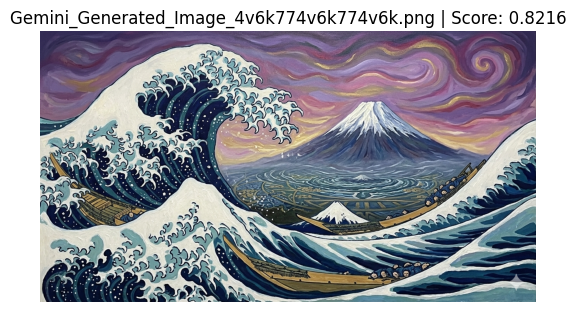

Gemini_Generated_Image_cf3l0gcf3l0gcf3l.png → Similarity: 0.8166


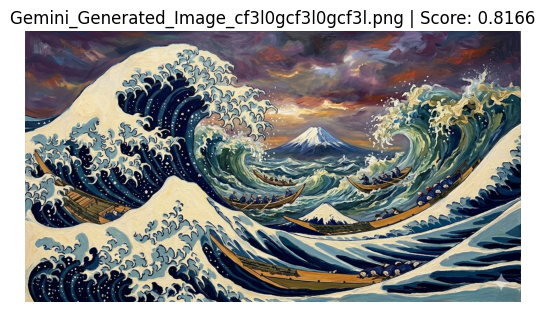

Gemini_Generated_Image_14yzij14yzij14yz.png → Similarity: 0.7396


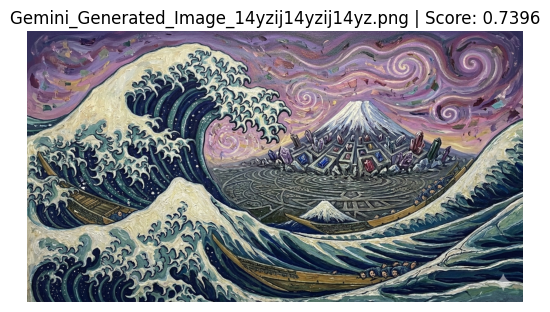

other2.jpg → Similarity: 0.4680


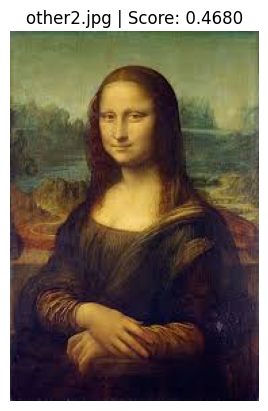

In [17]:
print("\nTop Similar Images:\n")

for file, score in results:
    print(f"{file} → Similarity: {score:.4f}")

    img = cv2.imread(os.path.join(ai_folder, file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(f"{file} | Score: {score:.4f}")
    plt.axis("off")
    plt.show()